In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2



d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
IMAGE_DIR = "D:/FY_Project/Ai-CDD/data/raw/segmentation_sample/images"
MASK_DIR  = "D:/FY_Project/Ai-CDD/data/raw/segmentation_sample/masks"

IMG_SIZE = 256

def load_image_mask(image_path, mask_path, img_size=256):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(image, (img_size, img_size))
    mask  = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)

    image = image.astype(np.float32) / 255.0
    mask = (mask > 0).astype(np.uint8)

    image = np.expand_dims(image, axis=-1)
    mask  = np.expand_dims(mask, axis=-1)

    return image, mask

def load_dataset(image_dir, mask_dir):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))

    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file.replace(".png", "_mask.png"))

        if not os.path.exists(mask_path):
            continue

        img, mask = load_image_mask(img_path, mask_path)
        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

X, Y = load_dataset(IMAGE_DIR, MASK_DIR)
print(X.shape, Y.shape)





(50, 256, 256, 1) (50, 256, 256, 1)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)


(40, 256, 256, 1) (10, 256, 256, 1)


In [4]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


In [5]:
def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = conv_block(p3, 512)

    # Decoder
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.Concatenate()([u5, c3])
    c5 = conv_block(u5, 256)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.Concatenate()([u6, c2])
    c6 = conv_block(u6, 128)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.Concatenate()([u7, c1])
    c7 = conv_block(u7, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    return models.Model(inputs, outputs)


In [6]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


In [7]:
model = build_unet()
model.compile(
    optimizer="adam",
    loss=lambda y_true, y_pred: dice_loss(y_true, y_pred)
                                 + tf.keras.losses.binary_crossentropy(y_true, y_pred),
    metrics=[dice_coef]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 7,781,761 (29.69 MB)

 Trainable params: 7,781,761 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=2
)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - dice_coef: 0.3192 - loss: 1.2529 - val_dice_coef: 0.2264 - val_loss: 1.8514
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 127s 6s/step - dice_coef: 0.3375 - loss: 1.2440 - val_dice_coef: 0.3861 - val_loss: 1.1864
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - dice_coef: 0.3963 - loss: 1.1036 - val_dice_coef: 0.4309 - val_loss: 1.0994
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step - dice_coef: 0.4184 - loss: 1.0643 - val_dice_coef: 0.5107 - val_loss: 0.9101
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 146s 7s/step - dice_coef: 0.4555 - loss: 1.0523 - val_dice_coef: 0.4581 - val_loss: 0.9808
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - dice_coef: 0.4977 - loss: 0.9748 - val_dice_coef: 0.4369 - val_loss: 0.9874
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 138s 7s/step - dice_coef: 0.5280 - loss: 0.8643 - val_dice_coef: 0.6124 - val_loss: 0.7296
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - dice_coef: 0.6627 - loss: 0.6674 - val_dice_

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


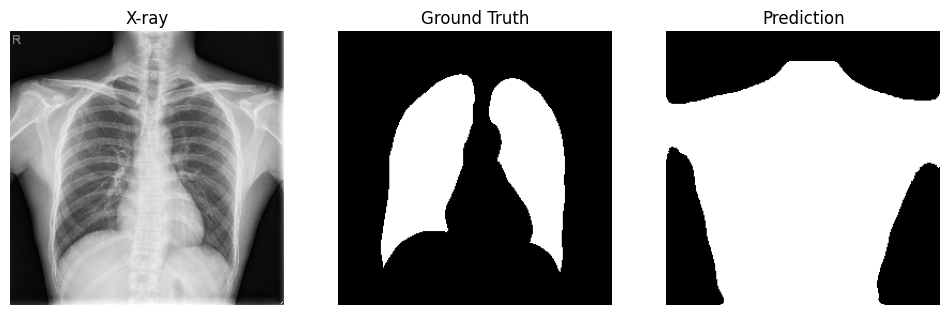

In [10]:
idx = np.random.randint(0, len(X_val))
pred = model.predict(X_val[idx:idx+1])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[idx].squeeze(), cmap="gray")
plt.title("X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred.squeeze() > 0.3, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()


In [11]:
# Evaluate model on validation/test data
results = model.evaluate(X_val, Y_val, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - dice_coef: 0.4182 - loss: 1.0565
loss: 1.0565
compile_metrics: 0.4182


In [13]:
import os

# Always save trained models here
SAVE_DIR = "D:\FY_Project\Ai-CDD\models_saved"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "unet_baseline.keras")

model.save(MODEL_PATH)

print("✅ Model saved at:", MODEL_PATH)


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\saving\serialization_lib.py:405: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true, y_pred: dice_loss(y_true, y_pred)

  return {key: serialize_keras_object(value) for key, value in obj.items()}


✅ Model saved at: D:\FY_Project\Ai-CDD\models_saved\unet_baseline.keras


In [16]:
import os

print("Files in models_saved:")
print(os.listdir("D:\FY_Project\Ai-CDD\models_saved"))


Files in models_saved:
['.gitkeep', 'unet_baseline.keras']


In [17]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "D:\FY_Project\Ai-CDD\models_saved/unet_baseline.keras",
    custom_objects={
        "dice_coef": dice_coef,
        "dice_loss": dice_loss
    },
    safe_mode=False   # 🔴 THIS IS THE FIX
)

print("✅ Model loaded successfully")


✅ Model loaded successfully


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


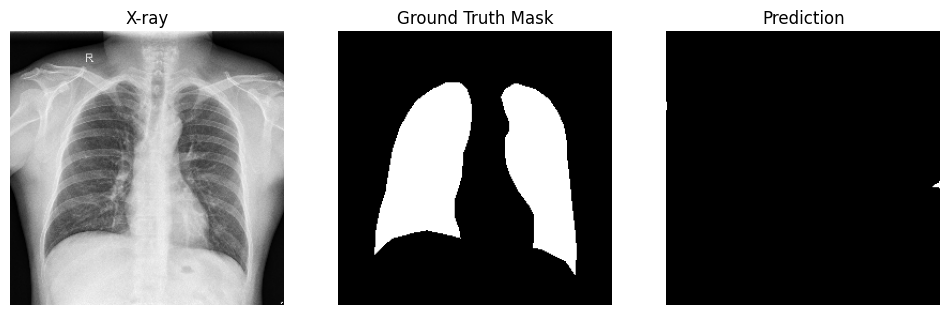

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


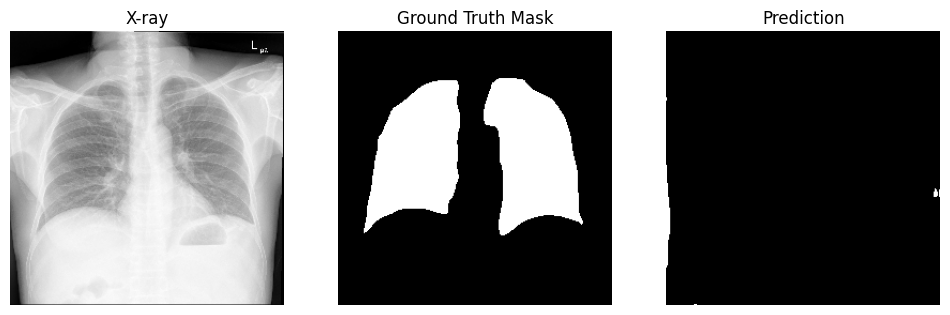

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


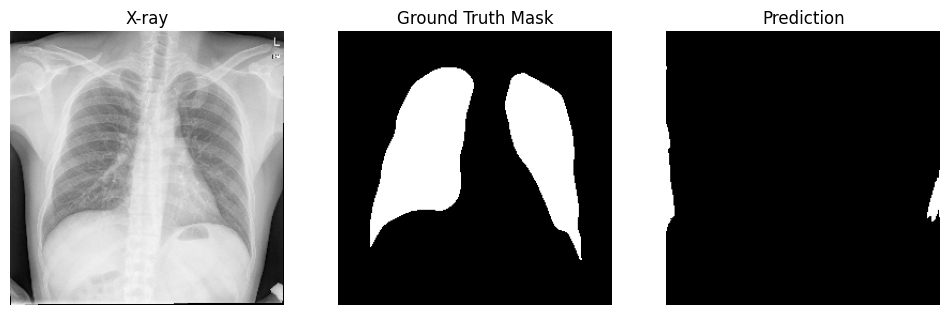

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Pick 3 random validation samples
idxs = np.random.choice(len(X_val), 3, replace=False)

for i, idx in enumerate(idxs):
    img = X_val[idx]
    mask = Y_val[idx]

    pred = loaded_model.predict(img[np.newaxis, ...])[0]
    pred_bin = (pred > 0.5).astype("uint8")

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("X-ray")
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth Mask")
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_bin.squeeze(), cmap="gray")
    plt.axis("off")

    plt.show()


In [21]:
import numpy as np

def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )


In [22]:
# Dummy test to confirm function works
y_true = np.array([[1, 1, 0, 0],
                   [1, 1, 0, 0]])

y_pred = np.array([[1, 0, 0, 0],
                   [1, 1, 0, 0]])

print("Dice:", dice_score(y_true, y_pred))


Dice: 0.85714287


In [23]:
dice_scores = []
THRESH = 0.3  # critical

for i in range(len(X_test)):
    img = X_test[i:i+1]          # (1, H, W, 1)
    true_mask = Y_test[i]        # (H, W, 1)

    pred = model.predict(img)[0]  # (H, W, 1)

    pred_bin = (pred > THRESH).astype(np.uint8)
    true_bin = (true_mask > 0.5).astype(np.uint8)

    dice = dice_score(true_bin, pred_bin)
    dice_scores.append(dice)

print("Mean Dice Score:", np.mean(dice_scores))


NameError: name 'X_test' is not defined

In [24]:
who = dir()
print("X_test" in who)
print("Y_test" in who)


False
False


In [25]:
from sklearn.model_selection import train_test_split

# Assuming X and Y already exist
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


X_test shape: (10, 256, 256, 1)
Y_test shape: (10, 256, 256, 1)


In [26]:
dice_scores = []
THRESH = 0.3

for i in range(len(X_test)):
    img = X_test[i:i+1]
    true_mask = Y_test[i]

    pred = model.predict(img)[0]

    pred_bin = (pred > THRESH).astype(np.uint8)
    true_bin = (true_mask > 0.5).astype(np.uint8)

    dice = dice_score(true_bin, pred_bin)
    dice_scores.append(dice)

print("Mean Dice Score:", np.mean(dice_scores))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Mean Dice Score: 0.5273133


In [27]:
import json

results = {
    "mean_dice_score": float(np.mean(dice_scores)),
    "num_validation_samples": len(X_val)
}

with open("D:\FY_Project\Ai-CDD\models_saved/segmentation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("✅ Results saved to segmentation_results.json")


✅ Results saved to segmentation_results.json


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Model loaded
Testing on: 0001.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


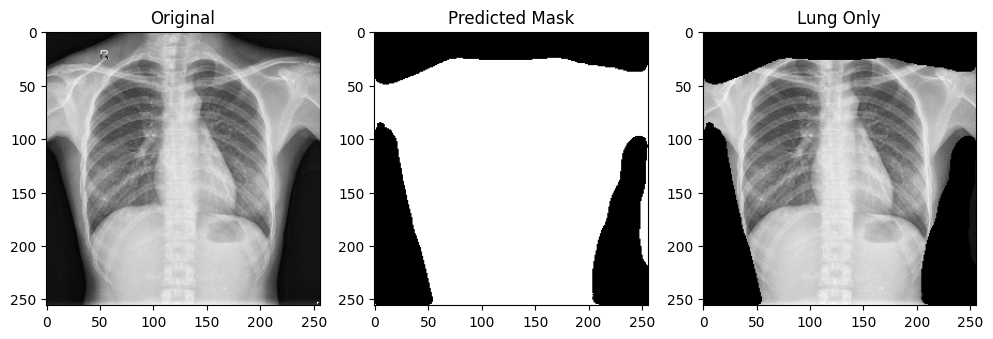

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# =========================
# PATHS (EDIT ONLY IF NEEDED)
# =========================
MODEL_PATH = r"D:\FY_Project\Ai-CDD\models_saved\unet_baseline.keras"
IMAGE_PATH = r"D:\FY_Project\Ai-CDD\data\raw\segmentation_sample\images"

IMG_SIZE = 256
THRESH = 0.3

# =========================
# Load model
# =========================
model = load_model(MODEL_PATH, compile=False)
print("Model loaded")

# =========================
# Pick ONE test image
# =========================
files = os.listdir(IMAGE_PATH)
test_file = files[0]   # first image
print("Testing on:", test_file)

img_path = os.path.join(IMAGE_PATH, test_file)

# =========================
# Preprocess
# =========================
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_norm = img / 255.0
img_input = np.expand_dims(img_norm, axis=(0, -1))

# =========================
# Predict mask
# =========================
pred_mask = model.predict(img_input)[0]
binary_mask = (pred_mask > THRESH).astype(np.uint8)

# =========================
# Apply mask
# =========================
lung_only = img_norm * binary_mask.squeeze()

# =========================
# Show results
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_norm, cmap="gray")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(binary_mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Lung Only")
plt.imshow(lung_only, cmap="gray")

plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# =========================
# SETTINGS
# =========================
MODEL_PATH = r"D:\FY_Project\Ai-CDD\models_saved\unet_baseline.keras"
IMG_SIZE = 256
THRESH = 0.3

# =========================
# Load trained model
# =========================
model = load_model(MODEL_PATH, compile=False)
print("Model loaded")

# =========================
# Pick image manually
# =========================
Tk().withdraw()
file_path = askopenfilename(title="Select X-ray")

if not file_path:
    print("No file selected")
else:
    print("Processing:", file_path)

    # Read image
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    img_norm = img / 255.0
    img_input = np.expand_dims(img_norm, axis=(0, -1))

    # Predict mask
    pred = model.predict(img_input)[0]
    mask = (pred > THRESH).astype(np.float32)

    # Apply mask
    lung_only = img_norm * mask.squeeze()

    # =========================
    # SHOW ONLY FINAL RESULT
    # =========================
    plt.figure(figsize=(4,4))
    plt.imshow(lung_only, cmap="gray")
    plt.axis("off")
    plt.title("Segmented Lung Output")
    plt.show()


Model loaded


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading model...
Reading image...
Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Displaying result...


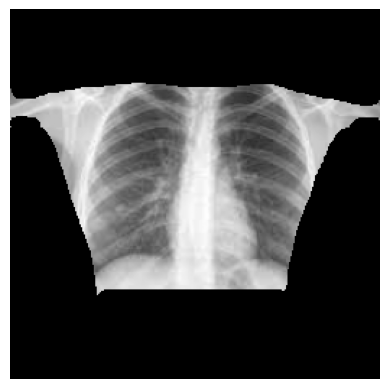

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# =========================
# CHANGE ONLY THIS LINE
# =========================
IMAGE_PATH = r"C:\Users\edric\Downloads\sample4.jfif"

MODEL_PATH = r"D:\FY_Project\Ai-CDD\models_saved\unet_baseline.keras"
IMG_SIZE = 256
THRESH = 0.3

print("Loading model...")
model = load_model(MODEL_PATH, compile=False)

print("Reading image...")
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

img_norm = img / 255.0
img_input = np.expand_dims(img_norm, axis=(0, -1))

print("Predicting...")
pred = model.predict(img_input)[0]

mask = (pred > THRESH).astype(np.float32)
lung_only = img_norm * mask.squeeze()

print("Displaying result...")
plt.imshow(lung_only, cmap="gray")
plt.axis("off")
plt.show()
